# TS5: Estimación espectral: Ancho de banda de señales reales

### Gonzalo Constenla

[Nbviewer](https://nbviewer.org/github/GConstenlaP/AyPS/blob/main/TS5/TS5.ipynb)
[GitHub](https://github.com/GConstenlaP/AyPS/blob/main/TS5/TS5.ipynb)

## Introducción
El objetivo del presente trabajo es leer y analizar distintas señales de distintos tipos y determinar por medio de un metodo de estimación espectral a elección personal (entre los vistos en el curso), la respectiva Densidad espectral de potencia (PSD) de la señal y su ancho de banda.

#### Marco Teórico
La Herramienta formal que define la densidad espectral de potencia (Psd) de un proceso aleatorio estacionario en sentido amplio(Aquel cuyas variables estadísticas no cambian con el tiempo) es la transformada de Fourier de tiempo discreto (DTFT) de su secuencia de aautocorrelación $r_x(k)$:
$$r_x(k) = \lim_{N \to \infty} \frac{1}{2N + 1} \sum_{n=-N}^{N} x(n + k)x^*(n)$$

$$P_x(e^{j\omega}) = \sum_{k=-\infty}^{\infty} r_x(k) e^{-j k \omega}$$

El problema es que, en una señal Real, no conocemos la secuencia real de autocorrelación teórica, ya que para ello deberíamos conocer las infinitas muestras desde $n = -\infty$ hasta $+\infty$, lo cual resulta físicamente imposible.


A raiz de esto, surgieron 2 enfoques principales de estimación:

*Método de Blackman-Tukey:* Trabajar en el dominio temporal, definiendo un estimador para la autocorrelación de la señal $\hat{r}_x(k)$ a partir de un número finito de muestras, aplicar una ventana y luego calcular la Transofrmada de Fourier y terminar de obtener la PSD.

Por otro lado, como veniámos trabajando en el curso hasta el momento, se puede trabajar en el dominio de la frecuencia, Con el *Periodograma clásico:* a partir de las muestras $x(n)$, aplicamos la DFT y luego calculando su módulo al cuadrado y normalizando por N muestras, obteniamos el estimador de la PSD:
$$\hat{P}_{xx}(e^{j\omega}) = \frac{1}{N} \left\vert{} \sum_{n=0}^{N-1} x(n) e^{-j \omega n} \right\vert{}^2$$

Los principales problemas con este método es que para finitas muestras es un estimador sesgado, ya demas es inconsistente ya que para infinitas muestras su varianza no tiende a cero, sino que tiende a la potencia media de la señal al cuadrado, es decir que tomar mas muestras no me garantiza menor varianza, sino lo contrario.

Para atacar este problema surgieron distintos métodos, primero el *periodograma modificado*, que consiste en la aplicación de una ventana, el cual tiene menor sesgo, pero una varianza similar.

Luego el *método Barlett* que consiste en la division de las muestras totales N en K bloques de Longitud de L muestras, con este método se obtienen K periodogramas que luego se promedian. De esta forma se obtuvo un estimador consistente de la PSD, ya que la Varianza es proporcional a 1/K, a costa de resolución espectral.

Por un Lado se mejoro el Sesgo con el Periodograma modificado, Por otro se mejoro la varianza con el método Barlett, a partir de estas ideas, nació el *Método Welch*, el cual será utilizado en este trabajo, ya que divide las N muestras, en K bloques de longitud L, aplicando una ventana en cada bloque, ademas introduciendo el concepto de solapamiento, típicamente del 50% ya que, de esta forma, las muestras que en un bloque se cancelan por estar en los bordes de la ventana donde la magnitud se anula, en el bloque siguiente se encuentran en y cerca del máximo. 

El estimador del periodograma modificado de la $i$-ésima sección con solapamiento se define como:
$$\hat{W}_W^{(i)}(e^{j\omega}) = \frac{1}{LU} \left\vert{} \sum_{n=0}^{L-1} w(n) x(n + iD) e^{-j\omega n} \right\vert{}^2$$

Donde $U$ es un factor de normalización de energía de la ventana: 

$$U = \frac{1}{L} \sum_{n=0}^{L-1} \vert{}w(n)\vert{}^2$$

Y el estimador final de Welch resulta del promedio de los $K$ periodogramas modificados y solapados: 
$$\hat{P}_{Welch}(e^{j\omega}) = \frac{1}{K} \sum_{i=0}^{K-1} \hat{W}_W^{(i)}(e^{j\omega})$$

Este método posee una reducción del 50% de la varianza que el método Barlett, para las mismas cantidades de muestras N y L.

## Desarrollo



Importo librerias y defino función que toma como parametros la señal, la frecuencia de muestreo, la ventana que quiera aplicar, el tamaño del bloque en muestras(L) y el porcentaje que quiera determinar como limite para definir el ancho de banda de la señal.
En este trabajo se utilizo la ventana Hann y el ancho de banda encerrando 98% de la potencia de las frecuencias de la señal.
Además se trabajaron con distintos tamaños de bloque, probando distinto numero de muestras por bloque, para observar su influencia en los resultados. 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

from scipy import signal as sig
import scipy.io as sio
from scipy.io.wavfile import write

import sounddevice as sd


import os

#en que carpeta estoy
#print(os.getcwd())

#agrego mi carpeta al directorio
os.chdir(r'C:\Users\Gonza\AyPS\Repositorio AyPS Git\TS5')

#importo lib de señales
import scipy.signal.windows as win

from scipy import signal

def calcular_psd_y_bw(x, fs, ventana, nperseg, porcentaje):

    f, Pxx = signal.welch(
        x,
        fs=fs,
        window=ventana,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        nfft=None,
        detrend='constant',
        return_onesided=True,
        scaling='density',
        axis=-1,
        average='mean'
    )
    

    df = f[1] - f[0]

    potencia_acum = np.cumsum(Pxx) * df
    potencia_total = potencia_acum[-1]

    bw = f[np.where(potencia_acum >= porcentaje * potencia_total)[0][0]]

    return f, Pxx, bw

### Señal 1: Electrocardiograma
Se guardaron las muestras del electrocardiograma leidas con una frecuencia de muestreo de 1000hz.
Y se Obtuvieron 30k muestras.

Se realizaron las gráficas de la PSD de la señal con bloques de muestras L=1000, 2000 y 8000, lo que resulta en 59, 29 y 6 bloques respectivamente, obtenidos a partir de la fórmula para el cálculo de bloques $K$ con desplazamiento D(Obtenido a partir del Solapamiento):$$K = \lfloor \frac{N - L}{D} \rfloor + 1$$

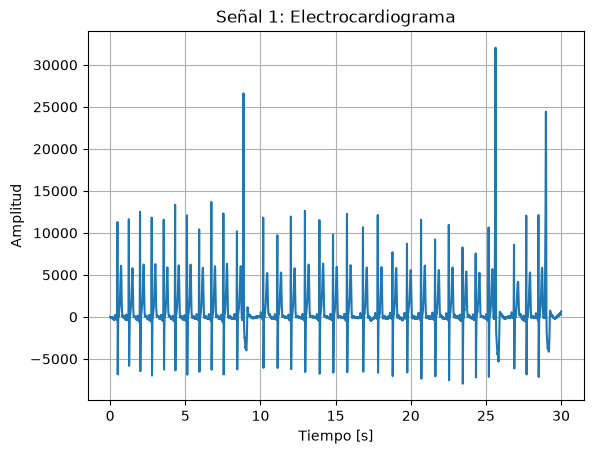

Ancho de banda de 98% potencia de ECG con bloques de 1000 muestras : 27.000 Hz
Varianza teórica estimada del estimador: 3883968.25000



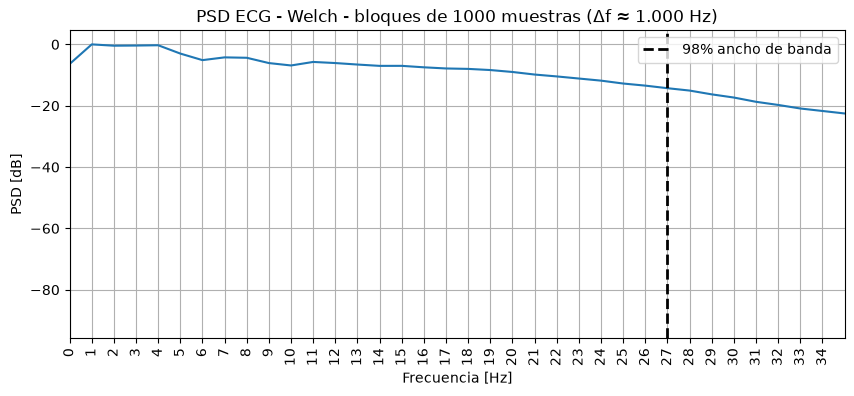

Ancho de banda de 98% potencia de ECG con bloques de 2000 muestras : 27.000 Hz
Varianza teórica estimada del estimador: 8307603.50000



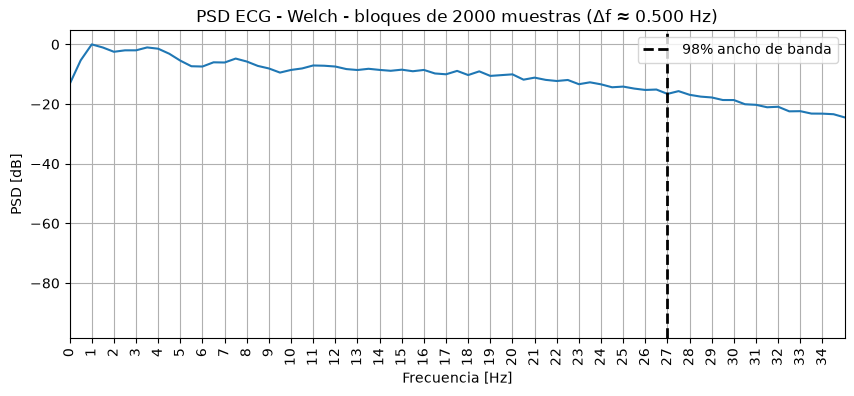

Ancho de banda de 98% potencia de ECG con bloques de 8000 muestras : 27.875 Hz
Varianza teórica estimada del estimador: 23558542.00000



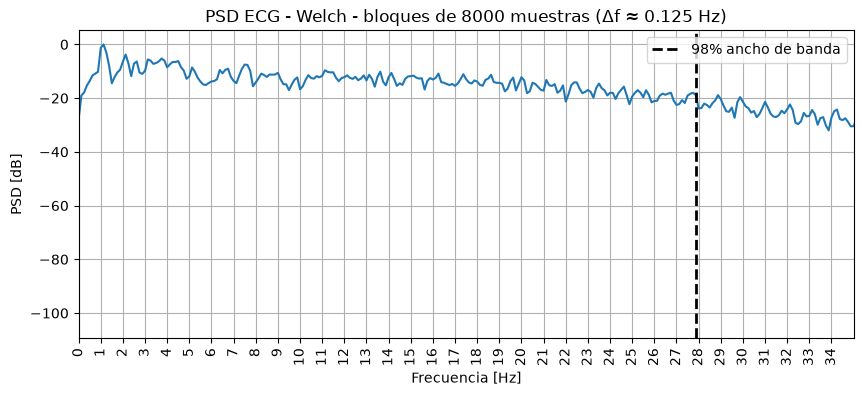

In [18]:
#%% ################### Lectura de ECG sin ruido ###################

fs_ecg = 1000 # Hz

ecg_one_lead = np.load('ecg_sin_ruido.npy')

#los tiempos: son el vector de las muestras divido la frecuencia
t_ecg = np.arange(len(ecg_one_lead)) / fs_ecg

#print(len(ecg_one_lead)) #tengo 30mil muestras
#la resolucion frecuencial, deltaf es = fs/nperseg, ya que nperseg son las muestras de cada bloque
# con nperseg mas chico tengo mas bloques, entonces tengo menos varianza pero menor resulcion espectral.


plt.figure()
plt.title('Señal 1: Electrocardiograma')
plt.grid()
plt.plot(t_ecg, ecg_one_lead)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.show()

# Grafico para bloques de 1000, 2000, etc muestras
nperseg_values = [1000,2000,8000]

for nperseg in nperseg_values:
# UTLIZIZO VENTANA HANN

# UTLIZIZO VENTANA HANN 
    f_ecg, Pxx_ecg, bw_ecg = calcular_psd_y_bw(ecg_one_lead, fs_ecg, ventana = 'hann', nperseg = nperseg, porcentaje = 0.98)
    print(f'Ancho de banda de 98% potencia de ECG con bloques de {nperseg} muestras : {bw_ecg:.3f} Hz')

      
    L = nperseg
    var_teorica = (9 * L / (16 * len(ecg_one_lead))) * (np.mean(Pxx_ecg)**2)
    print(f'Varianza teórica estimada del estimador: {var_teorica:.5f}\n')

    
    Pxx_norm = Pxx_ecg / np.max(Pxx_ecg) # PSD en dB
    Pxx_db = 10 * np.log10(Pxx_norm)
    plt.figure(figsize=(10, 4))
    plt.plot(f_ecg, Pxx_db)
    plt.xlim(0, 35)
    plt.xticks(np.arange(0, 35, 1), rotation=90)
    plt.xlabel('Frecuencia [Hz]')
    plt.axvline(bw_ecg, color='black', linestyle='dashed', linewidth=2, label='98% ancho de banda')
    plt.ylabel('PSD [dB]')
    plt.title(f'PSD ECG - Welch - bloques de {nperseg} muestras (Δf ≈ {fs_ecg/nperseg:.3f} Hz)')
    plt.grid()
    plt.legend(loc='upper right')
    plt.show()




Para mayor numero de muestras por bloque, tengo menos bloques, por lo tanto al promediar menos las muestras, la varianza obtenida resulta mayor, sin embargo se puede observar a partir de las gráficas obtenidas que mejora la resolucion espectral y se pueden apreciar mejor componentes de frecuencia donde hay máximos locales de potencia, que Usando welch con mas bloques no se ven.

En mi caso experimente medir el ancho de banda con distintos porcentajes, y cada uno de los ultimos percentiles ocupan mas hz de frecuencia que contienen menos potencia y finalmente decidi tomar el 98% de la potencia de la señal. Se ve que en el caso del electrocardiograma la gran mayoria de la potencia se concentra en bajas frecuencias, sin ver mucha varianza entre las estimaciones con 59, 29 y 6 bloques, obteniendo un ancho de banda alrededor de 27-28hz.

Se ve que al usar L = 8000, gracias a una mejor resolucion espectral, se pueden distinguir mucho mejor algunos componentes, sin embargo tambien se pueden ver mayor numero de oscilaciones, debido al aumento de la varianza.

Además el resultado del ancho de banda es consistente con la documentación sobre las frecuencias de la Onda P(5 a 30hz) y complejo QRS (0 a 40hz), que contienen varias componentes frecuenciales y armónicos en frecuencias mas altas.

### Señal 2: pletismografía
Este señal fue muestreada con una frecuencia de 400hz y se uso Welch con L = 400, 800 y 3200.

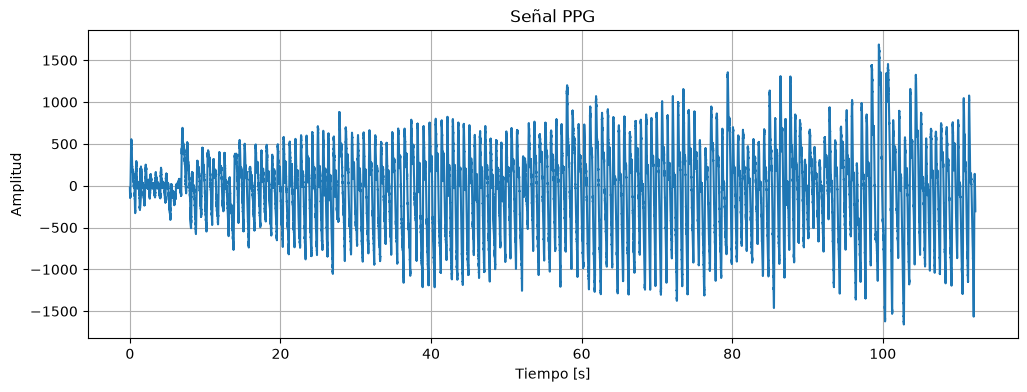

Ancho de banda de 98% potencia de PPG con bloques de 400 muestras : 5.000 Hz


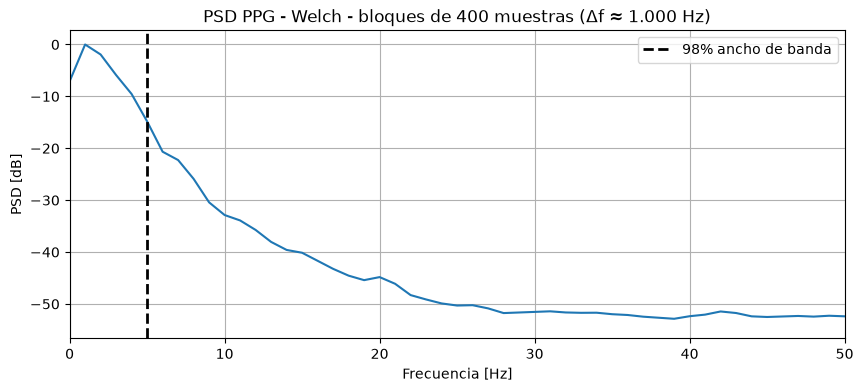

Ancho de banda de 98% potencia de PPG con bloques de 800 muestras : 4.500 Hz


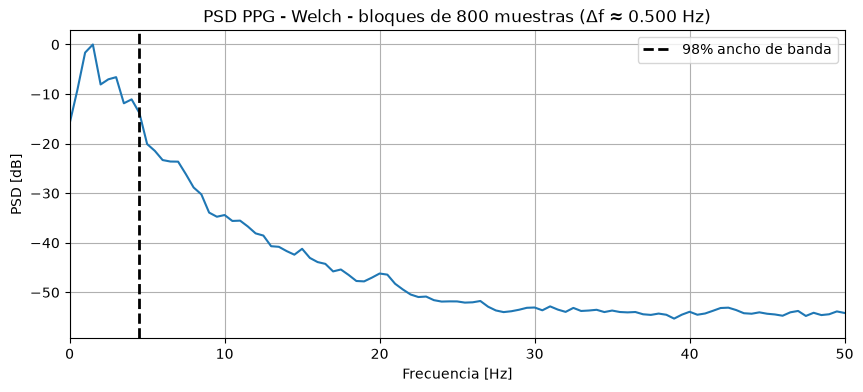

Ancho de banda de 98% potencia de PPG con bloques de 3200 muestras : 4.375 Hz


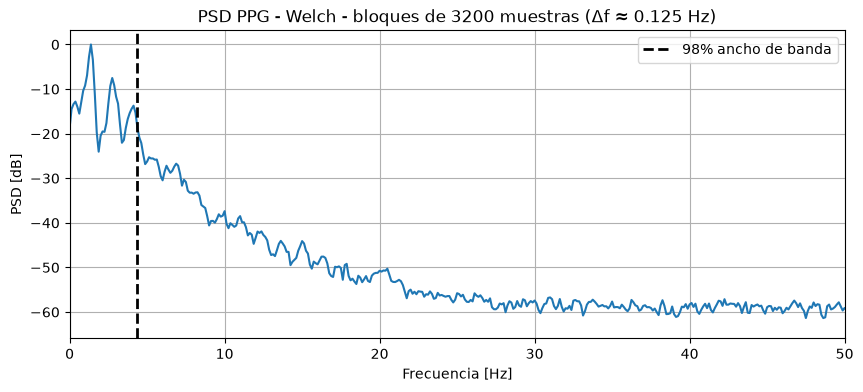

In [10]:
#%% ##################################### Lectura de pletismografía (PPG)  #####################################

fs_ppg = 400 # Hz

##################
## PPG sin ruido
##################

ppg = np.load('ppg_sin_ruido.npy')

N_ppg = len(ppg)
t_ppg = np.arange(N_ppg) / fs_ppg
# print(f'Cantidad de muestras: {N_ppg}') # 44919 muestras y 112.3 s de duracion

plt.figure(figsize=(12, 4))
plt.plot(t_ppg, ppg)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal PPG')
plt.grid()
plt.show()


# Como tengo n = 44919 y fs = 400hz

nperseg_values_ppg = [400, 800, 3200]
    
for nperseg1 in nperseg_values_ppg:
# UTLIZIZO VENTANA HANN
    f_ppg, Pxx_ppg, bw_ppg = calcular_psd_y_bw(ppg, fs_ppg, ventana = 'hann', nperseg =  nperseg1, porcentaje = 0.98)
    print(f'Ancho de banda de 98% potencia de PPG con bloques de {nperseg1} muestras : {bw_ppg:.3f} Hz')

    Pxx_ppg_norm = Pxx_ppg / np.max(Pxx_ppg)
    # PSD en dB
    Pxx_ppg_db = 10 * np.log10(Pxx_ppg_norm)


    plt.figure(figsize=(10, 4))
    plt.plot(f_ppg, Pxx_ppg_db)
    # plt.xlim(0, 35)
    # plt.xticks(np.arange(0, 35, 1), rotation=90)
    plt.xlabel('Frecuencia [Hz]')
    plt.xlim(0,50)
    plt.axvline(bw_ppg, color='black', linestyle='dashed', linewidth=2, label='98% ancho de banda')
    plt.ylabel('PSD [dB]')
    plt.title(f'PSD PPG - Welch - bloques de {nperseg1} muestras (Δf ≈ {fs_ppg/nperseg1:.3f} Hz)')
    plt.grid()
    plt.legend(loc='upper right')
    plt.show()

En este caso, la varianza en el resultado entre las 3 medidas resulto mayor, para los bloques de los 3 tamaños, el ancho de banda se movio entre 5 y 4.375hz, es decir hubo mas de un 10% de diferencia en la estimación con L=400 y L=3200. Yo creo que en este caso, donde el ancho de banda se concentra en frecuencias: 0-5hz, el hecho de haber seleccionado L = 400, tal que obtengo una resolucion frecuencial de 1hz, me genera poca precision en los resultados, ya que la resolucion espectral es igual a un quinto del ancho de banda total obtenido para ese L y resulta insuficiente para poder apreciar componentes frecuenciales con precisión.
Por lo cual se puede deducir que es mejor tomar menos bloques, pero con mas muestras para estas condiciones: esta señal y esta frecuencia de muestreo y concluyo que es mejor aproximación la medición con 3200 muestras por bloque.

### Señal 3: Distintas Señales de Audio
A partir de acá analizaré distintas señales de audio, por lo cual espero que que el anchod ebanda cambie significativamente, incluso teniendo intervalos mas grandes, teniendo en cuenta que la audición humana es sensible a frecuencias de 20 hasta 20k hz. Por esto, aca tambien aplicare un minimo, ademas una frecuencia máxima, de forma que ambos acoten la señal al 98% de la potencia, para lo cual introduzco una nueva funcion.

Se analizara las señales de audio muestreadas a 48khz que cuentan con 144000 muestras, lo que equivale a 3s de audio. Se va a aplicar el metodo de welch variando el tamaño del bloque en: 1000, 24000 y $48000 muestras (L) en cada señal de audio.
#### Audio 1: "La cucaracha"

Cantidad de muestras: 144000


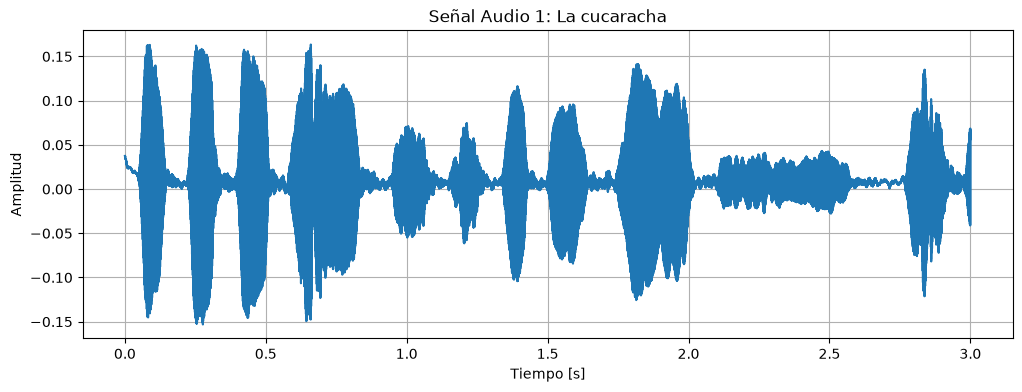

Audio 1 - nperseg=1000: BW98 = 1008.0 Hz (Desde 1008.0 Hz hasta 2016.0 Hz)


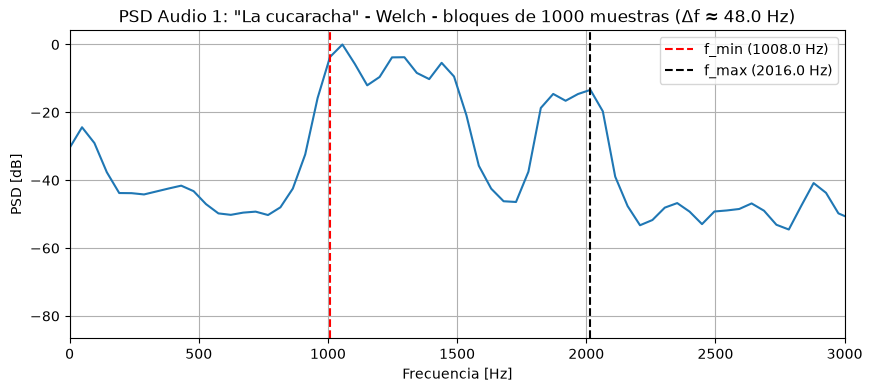

Audio 1 - nperseg=24000: BW98 = 1018.0 Hz (Desde 1000.0 Hz hasta 2018.0 Hz)


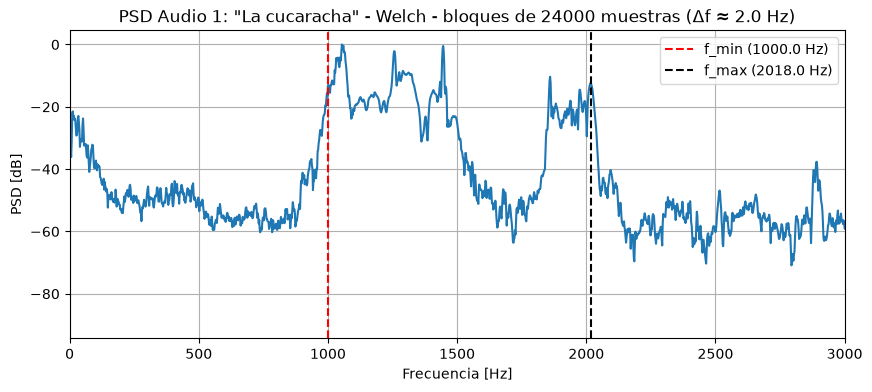

Audio 1 - nperseg=48000: BW98 = 1019.0 Hz (Desde 1000.0 Hz hasta 2019.0 Hz)


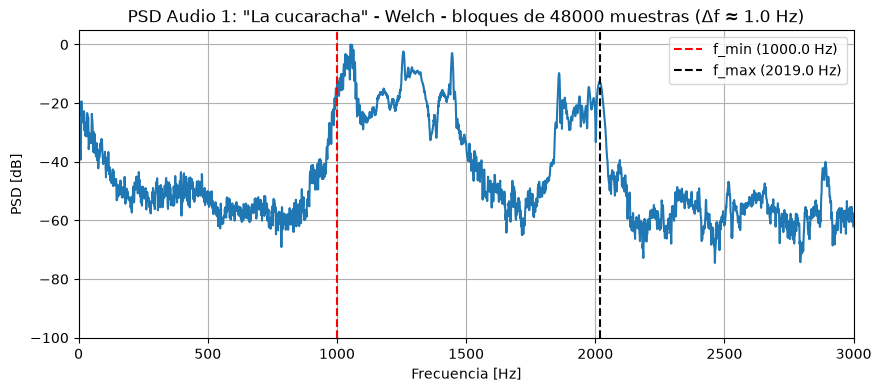

In [11]:
# %% ##################################### Lectura audios#####################################

def calcular_psd_y_bw(x, fs, ventana, nperseg, porcentaje):

    f, Pxx = signal.welch(
        x,
        fs=fs,
        window=ventana,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        nfft=None,
        detrend='constant',
        return_onesided=True,
        scaling='density',
        axis=-1,
        average='mean'
    )

    df = f[1] - f[0]

    # Cálculo de la potencia acumulada
    potencia_acum = np.cumsum(Pxx) * df
    potencia_total = potencia_acum[-1]

    # Porcentaje de potencia que queda fuera del intervalo
    porcentaje_fuera = 1 - porcentaje

    # Se distribuye el porcentaje fuera del intervalo
    # en partes iguales entre las frecuencias mínima y máxima
    porcentaje_min = porcentaje_fuera / 2
    porcentaje_max = 1 - porcentaje_fuera / 2

    # Frecuencia mínima que delimita el intervalo de potencia
    indice_min = np.where(
        potencia_acum >= porcentaje_min * potencia_total
    )[0][0]

    f_min = f[indice_min]

    # Frecuencia máxima que delimita el intervalo de potencia
    indice_max = np.where(
        potencia_acum >= porcentaje_max * potencia_total
    )[0][0]

    f_max = f[indice_max]

    # Ancho del intervalo de frecuencias que contiene
    # el porcentaje de potencia especificado
    bw = f_max - f_min

    return f, Pxx, f_min, f_max, bw
# %% 

fs_audio, audio1 = sio.wavfile.read('la cucaracha.wav')
fs_audio, audio2  = sio.wavfile.read('prueba psd.wav')
fs_audio, audio3 = sio.wavfile.read('silbido.wav')

#fs es 48khz
N_audio1 = len(audio1)
t_audio1 = np.arange(N_audio1) / fs_audio

print(f'Cantidad de muestras: {N_audio1}') # 144000


plt.figure(figsize=(12, 4))
plt.plot(t_audio1, audio1)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal Audio 1: La cucaracha')
plt.grid()
plt.show()


nperseg_values_audio1 = [1000, 24000, 48000]
    
for nperseg_audio1 in nperseg_values_audio1:
    f_audio1, Pxx_audio1, f_min_1, f_max_1, bw_audio1 = calcular_psd_y_bw(
        audio1, fs_audio, ventana='hann', nperseg=nperseg_audio1, porcentaje=0.98
    )
    print(f'Audio 1 - nperseg={nperseg_audio1}: BW98 = {bw_audio1:} Hz (Desde {f_min_1:} Hz hasta {f_max_1:} Hz)')

    Pxx_audio1_norm = Pxx_audio1 / np.max(Pxx_audio1)
    Pxx_audio1_db = 10 * np.log10(Pxx_audio1_norm)

    plt.figure(figsize=(10, 4))
    plt.plot(f_audio1, Pxx_audio1_db)
    plt.xlim(0, 3000)
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [dB]')
    plt.axvline(f_min_1, color='red', linestyle='dashed', linewidth=1.5, label=f'f_min ({f_min_1} Hz)')
    plt.axvline(f_max_1, color='black', linestyle='dashed', linewidth=1.5, label=f'f_max ({f_max_1} Hz)')
    plt.title(f'PSD Audio 1: "La cucaracha" - Welch - bloques de {nperseg_audio1} muestras (Δf ≈ {fs_audio/nperseg_audio1} Hz)')
    plt.grid()
    plt.legend(loc='upper right')
    plt.show()


En este caso, al tomar bloques de 1000 muestras, a pesar de tener muchas muestras totales, obtengo muy poca resolucion frecuencial, debido a que la frecuencia de muestreo es muy alta. Obtengo resolucion f. = 48hz, el cual es un numero muy elevado que deja de distinguir entre varios posibles componentes frecuenciales. Para tomar de referencia, el humano es capaz de distinguir con facilidad frecuencias de 10hz de diferencia en el rango de 1000 a 2000hz.
En las gráficas se puede apreciar que la potencia esta concentrada entre 1000hz y 2020 hz aproximadamente, con varios picos principales entre medio, y fuera del ancho de banda determinado, la señal cae abruptamente. Además se puede confirmar que tiene mucho mas sentido tomar también un minímo para el ancho de banda, ya que la potencia de los primeros 1000hz es insignificante comparada al ancho de banda obtenido.

#### Audio 2: "Prueba PSD"
La voz humana se sitúa en componentes de principalmente de 50 a 400hz, y si tenemos en cuenta los armónicos, la mayoria de la potencia abarca un intervalo mucho mayor hasta varios miles de hercios.

Audio 2 - Cantidad de muestras: 144000
Audio 2 - Duración: 3.0 s


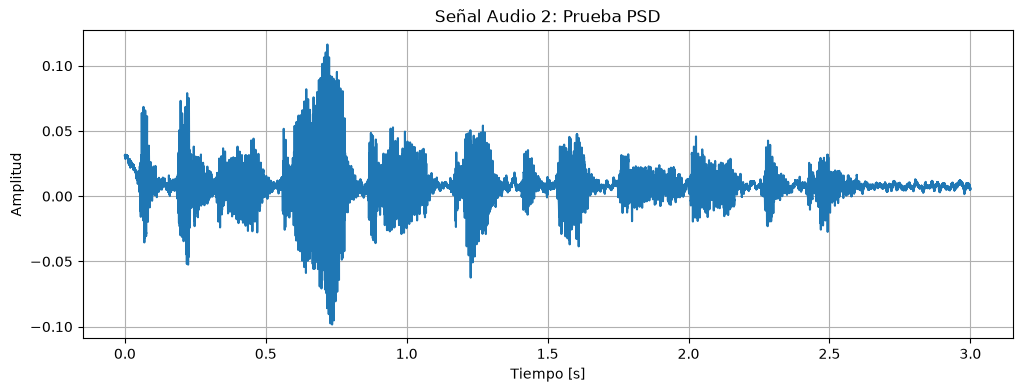

Audio 2 - nperseg=1000: Δf ≈ 48.0 Hz, BW98 = 2592.0 Hz (Desde 48.0 Hz hasta 2640.0 Hz)


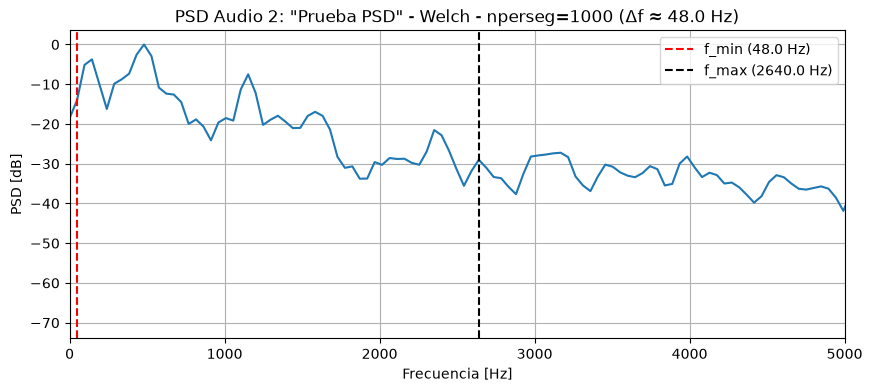

Audio 2 - nperseg=24000: Δf ≈ 2.0 Hz, BW98 = 2668.0 Hz (Desde 36.0 Hz hasta 2704.0 Hz)


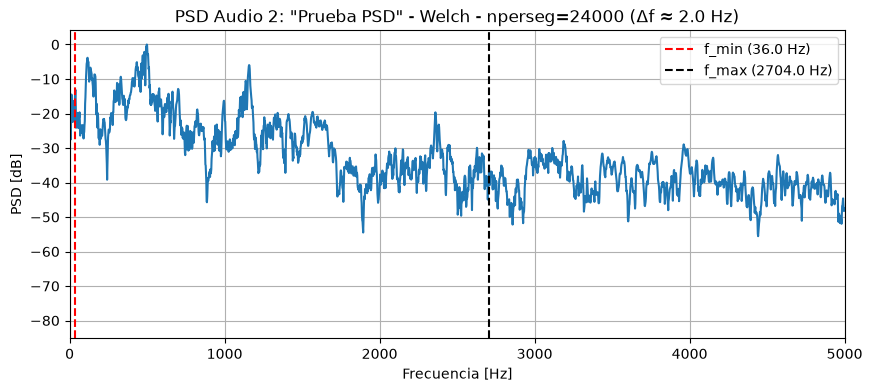

Audio 2 - nperseg=48000: Δf ≈ 1.0 Hz, BW98 = 2341.0 Hz (Desde 36.0 Hz hasta 2377.0 Hz)


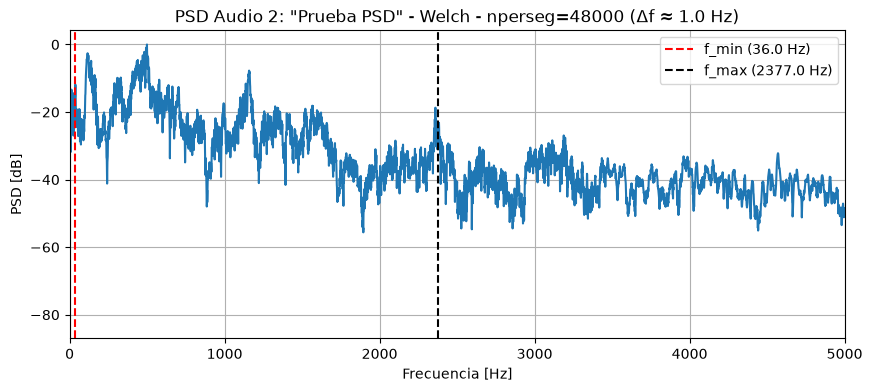

In [15]:
# %% ##################################### AUDIO 2 #####################################

N_audio2 = len(audio2)
t_audio2 = np.arange(N_audio2) / fs_audio

print(f'Audio 2 - Cantidad de muestras: {N_audio2}')
print(f'Audio 2 - Duración: {N_audio2/fs_audio} s')


# Señal temporal
plt.figure(figsize=(12, 4))
plt.plot(t_audio2, audio2)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal Audio 2: Prueba PSD')
plt.grid()
plt.show()


nperseg_values_audio2 = [1000, 24000, 48000]

nperseg_values_audio2 = [1000, 24000, 48000]

for nperseg_audio2 in nperseg_values_audio2:
    f_audio2, Pxx_audio2, f_min_2, f_max_2, bw_audio2 = calcular_psd_y_bw(
        audio2, fs_audio, ventana='hann', nperseg=nperseg_audio2, porcentaje=0.98
    )

    print(
        f'Audio 2 - nperseg={nperseg_audio2}: '
        f'Δf ≈ {fs_audio/nperseg_audio2:} Hz, '
        f'BW98 = {bw_audio2:} Hz (Desde {f_min_2:} Hz hasta {f_max_2} Hz)'
    )

    Pxx_audio2_norm = Pxx_audio2 / np.max(Pxx_audio2)
    Pxx_audio2_db = 10 * np.log10(Pxx_audio2_norm)

    plt.figure(figsize=(10, 4))
    plt.plot(f_audio2, Pxx_audio2_db)
    plt.xlim(0, 5000)
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [dB]')
    plt.axvline(f_min_2, color='red', linestyle='dashed', linewidth=1.5, label=f'f_min ({f_min_2} Hz)')
    plt.axvline(f_max_2, color='black', linestyle='dashed', linewidth=1.5, label=f'f_max ({f_max_2} Hz)')
    plt.title(
        f'PSD Audio 2: "Prueba PSD" - Welch - '
        f'nperseg={nperseg_audio2} '
        f'(Δf ≈ {fs_audio/nperseg_audio2} Hz)'
    )
    plt.grid()
    plt.legend(loc='upper right')
    plt.show()

De acuerdo a lo esperado se obtuvo una gráfica que presenta los máximos principales en los primeros 500hz, sin embargo la mayoria de la potencia cubre un ancho de banda de 36hz, las frecuencias mas graves del habla, hasta aproximadamente 2300, incluyendo la potencia significativa de los armonicos.

#### Audio 3: "Silbido"
En este caso, yo espero ver frecuencias mucho mas altas, ya que al tratarse de un silbido, tiene sentido esperarse ver mas potencia en componentes de frecuencias altos, por lo cual esperaria ver un ancho de banda mas extenso dependiendo la potencia del mínimo de la variación del silbido hallado.

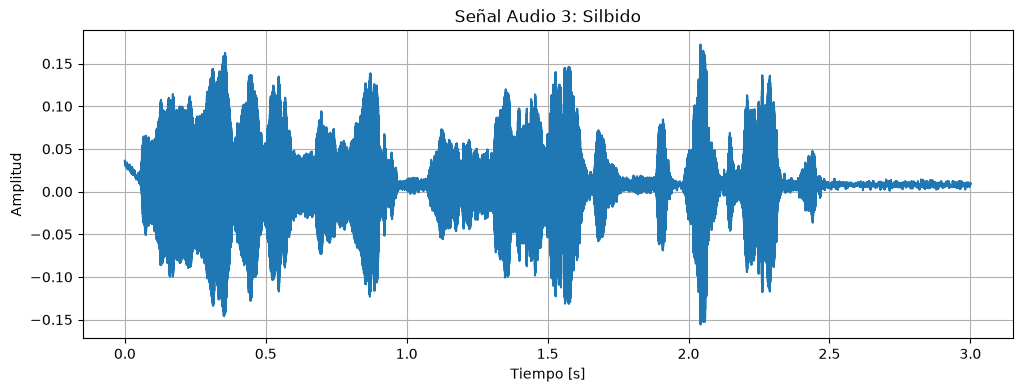

Audio 3 - nperseg=1000: Δf ≈ 48.0 Hz, BW98 = 3984.0 Hz (Desde 2688.0 Hz hasta 6672.0 Hz)


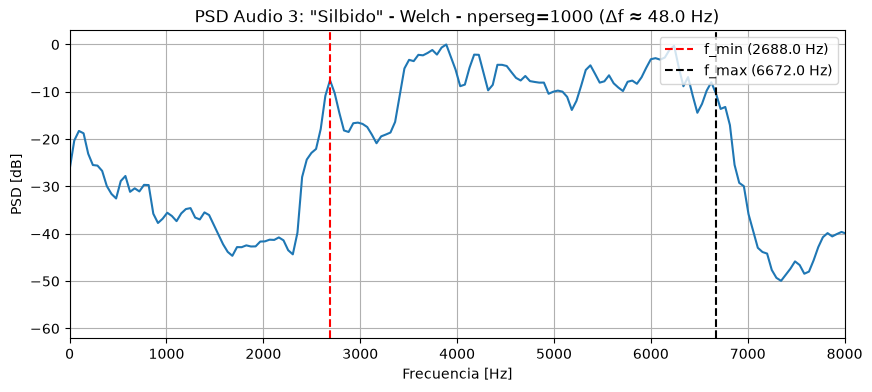

Audio 3 - nperseg=24000: Δf ≈ 2.0 Hz, BW98 = 3946.0 Hz (Desde 2676.0 Hz hasta 6622.0 Hz)


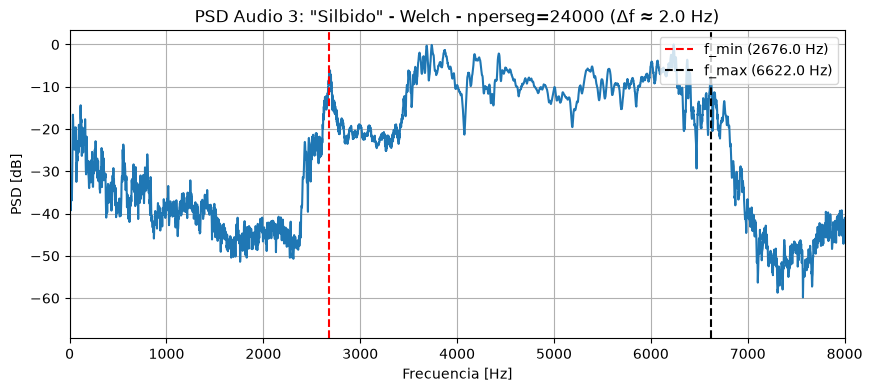

Audio 3 - nperseg=48000: Δf ≈ 1.0 Hz, BW98 = 3974.0 Hz (Desde 2683.0 Hz hasta 6657.0 Hz)


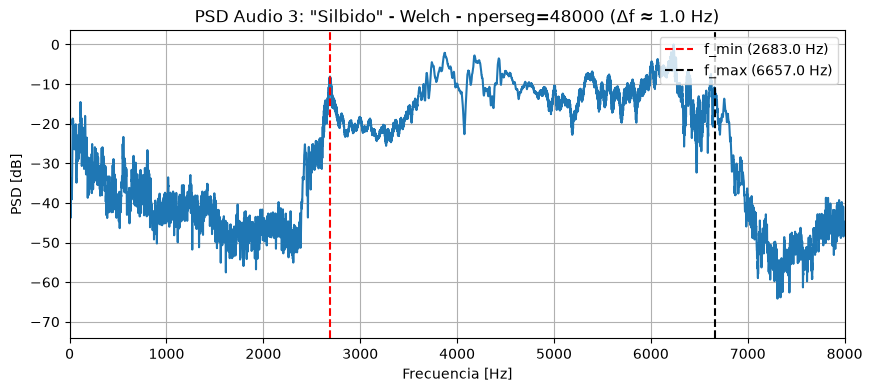

In [14]:
# %% audio 3

N_audio3 = len(audio3)
t_audio3 = np.arange(N_audio3) / fs_audio

plt.figure(figsize=(12, 4))
plt.plot(t_audio3, audio3)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal Audio 3: Silbido')
plt.grid()
plt.show()




# PSD mediante Welch
nperseg_values_audio3 = [1000, 24000, 48000]

for nperseg_audio3 in nperseg_values_audio3:
    f_audio3, Pxx_audio3, f_min_3, f_max_3, bw_audio3 = calcular_psd_y_bw(
        audio3, fs_audio, ventana='hann', nperseg=nperseg_audio3, porcentaje=0.98
    )

    print(
        f'Audio 3 - nperseg={nperseg_audio3}: '
        f'Δf ≈ {fs_audio/nperseg_audio3:} Hz, '
        f'BW98 = {bw_audio3} Hz (Desde {f_min_3} Hz hasta {f_max_3} Hz)'
    )

    Pxx_audio3_norm = Pxx_audio3 / np.max(Pxx_audio3)
    Pxx_audio3_db = 10 * np.log10(Pxx_audio3_norm)

    plt.figure(figsize=(10, 4))
    plt.plot(f_audio3, Pxx_audio3_db)
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [dB]')
    plt.xlim(0, 8000)
    plt.axvline(f_min_3, color='red', linestyle='dashed', linewidth=1.5, label=f'f_min ({f_min_3} Hz)')
    plt.axvline(f_max_3, color='black', linestyle='dashed', linewidth=1.5, label=f'f_max ({f_max_3} Hz)')
    plt.title(
        f'PSD Audio 3: "Silbido" - Welch - '
        f'nperseg={nperseg_audio3} '
        f'(Δf ≈ {fs_audio/nperseg_audio3:} Hz)'
    )
    plt.grid()
    plt.legend(loc='upper right')
    plt.show()
    

De acuero a lo esperado, esta vez obtuvimos un ancho de banda mucho mas extenso de aproximadamente 4000hz, debido a las variaciones en el tono del silbido y ademas se alcazaron frecuencias mucho mas altas, que corresponden a sonidos mas agudos.
A diferencia del audio anterior, de la voz, fuera del ancho de banda, se observa una caida abrupta en potencia, concentrandose la energía en los tonos frecuenciales del silbido.



In [21]:
print("--- Resumen de Anchos de Banda (98% de Potencia) ---")

print(f"Señal 1 - ECG (6 bloques de L = 8000): {bw_ecg} Hz")
print(f"Señal 2 - PPG (bloques de L = 3200): {bw_ppg} Hz")
print(f"Señal 3 - Audio 1 'La cucaracha' (L = 48000): desde {f_min_1} Hz hasta {f_max_1} Hz -> Ancho de Banda = {bw_audio1} Hz")
print(f"Señal 4 - Audio 2 'Prueba PSD' (L = 48000): desde {f_min_2} Hz hasta {f_max_2} Hz ->  Ancho de Banda = {bw_audio2} Hz")
print(f"Señal 5 - Audio 3 'Silbido' (L = 48000): desde {f_min_3} Hz hasta {f_max_3} Hz ->  Ancho de Banda = {bw_audio3} Hz")

--- Resumen de Anchos de Banda (98% de Potencia) ---
Señal 1 - ECG (6 bloques de L = 8000): 27.875 Hz
Señal 2 - PPG (bloques de L = 3200): 4.375 Hz
Señal 3 - Audio 1 'La cucaracha' (L = 48000): desde 1000.0 Hz hasta 2019.0 Hz -> Ancho de Banda = 1019.0 Hz
Señal 4 - Audio 2 'Prueba PSD' (L = 48000): desde 36.0 Hz hasta 2377.0 Hz ->  Ancho de Banda = 2341.0 Hz
Señal 5 - Audio 3 'Silbido' (L = 48000): desde 2683.0 Hz hasta 6657.0 Hz ->  Ancho de Banda = 3974.0 Hz


## Conclusión
A partir de la implementacion del método de welch para el análisis de señales biomédicas y señales de audio se pudieron sacar las siguientes conclusiones.
Se comprobo experimentalmente que al tomar mas muestras por bloque (L) se obtiene una gráfica mas densa $\Delta f = \frac{F_s}{L}$, permitiendo resolver picos de componentes de frecuencia mas cercanos, a costa de menos bloques, lo cual significa una mayor varianza al promediar.($\text{Var} \propto \frac{1}{K}$)

Principalmente en las señales acústicas se puede apreciar la importancia de tomar un ancho de banda limitado por minimo y máximo, ya que estas señales pueden tomar amplitudes muy dispares en un abánico muy amplio de frecuencias, como vimos con las 3 señales, tomando longitudes de ancho de banda distintos, ademas de minimos y maximos distintos. Esto resulta fundamental para el procesamiento de señales, acotando la señal, donde esta concentrada la mayor parte de energía.

Tambíen se reconoce la indispensibilidad del metodo de Welch para estimación de señales, ya que resulto útil para determinar el ancho de banda y estimar la potencia de señales con caracteristicas muy distintas, que a diferencia de otros metódos tiene la ventaja de que es personalizable con la ventana, numero de bloques y solapamiento a elección según la necesidad de adquirir mayor resolución espectral o reducir la varianza de la estimación.

